In [29]:

import numpy as np

import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import PillowWriter
from matplotlib.colors import LogNorm
import matplotlib.cm as cm
from matplotlib import patches
from astropy.wcs.utils import pixel_to_skycoord, skycoord_to_pixel
from regions import CircleSkyRegion, CirclePixelRegion
from scipy.interpolate import interp1d
import healpy as hp
from reproject import reproject_from_healpix
import json

import astropy
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import Angle, SkyCoord
import astropy.units as u
from astropy.wcs import utils as asutils
from astropy.visualization.wcsaxes.frame import EllipticalFrame

from scipy.optimize import curve_fit
from skimage.filters import difference_of_gaussians, window, gaussian
from skimage.io import imread, imshow
from skimage.feature import peak_local_max
from skimage import color, exposure, transform
from skimage.feature import blob_dog, blob_log, blob_doh

from scipy.ndimage import gaussian_filter

from helpers import *
%matplotlib inline

%load_ext autoreload
%autoreload 2
%reload_ext autoreload
milagrotextcolor, milagro = setupMilagroColormap(-3, 15, 2, 256)
milagrotextcolor2, milagro2 = setupMilagroColormap(0.2, 1, 2, 256)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
# filename = '/Users/rishi/Documents/Analysis/palmer/aerie-apps_bin4-9__allsky_1024_i2.5_r0.0_p1.0.fits.gz'
# filename = '/Users/rishi/Documents/Analysis/data/aligned-ml-wholesky-neg-ext0.0.fits.gz'
# filename = '/Users/rishi/Documents/Analysis/data/gr100-ext0p5-index2p7-padding1p0-bins_8910_GP.fits'
# filename = '/Users/rishi/Documents/Analysis/data/gr100-ext0p0-index2p7-padding1p0-bins_8910_GP.fits'
filename = "map.fits"
x = 230
y =  28
# x = 357.3
# y =  42.7
xlength = 14
ylength = 14
coord_sys = 'C' 
array, _, wcs, xnum, ynum, pixel_size = load_hawc_data(filename, x, y, xlength, ylength, coord_sys)

ROI center in Celestial Coordintes = 230, 28
Loading Celestial Map
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---MOL' 'DEC--MOL' 
CRVAL : 230.0 28.0 
CRPIX : 2520.0 2520.0 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.00277777777777777 0.002777777777777778 
NAXIS : 5040  5040
Fits File loaded
Degrees per pixel: 0.002777777777777778 


In [31]:
pixel_size

0.002777777777777778

Plotting contours [7, 9, 12, 13, 14, 15]
Peak intensity pixel location: (2401, 2856)
Peak intensity sky location: <SkyCoord (ICRS): (ra, dec) in deg
    (228.82564385, 27.69989336)>
Peak intensity value: 33.67956430348725


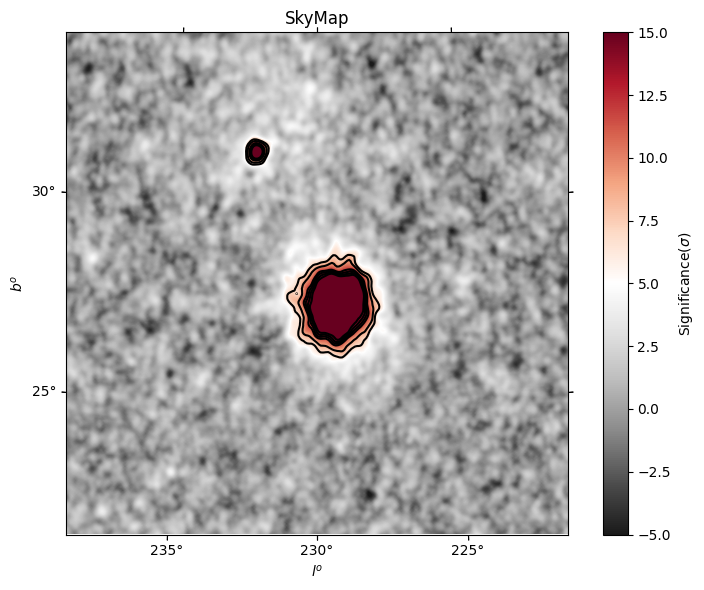

In [35]:
fig=make_plots(array, wcs, pixel_size, coordsys='G', threshold=3, vmin=-5, vmax=15, contour=True, title='SkyMap', hotspots=None, save_dir=None, pdf=False, cmap='RdGy_r', figsize=(10, 6), labels=['4afgl', 'pualsar', '4haawc', '1lhaaaso'])
find_peak(array, wcs)

In [14]:
# Stop if there are no hotspots greater than 5 sigma
if np.max(array) < 5:
    print(f'Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)')
    fig, ax = plt.subplots(figsize=(8.5, 11))  # Create a blank canvas (8.5x11 inches for letter size)
    ax.axis('off')  # Turn off axes
    text = f"Algorithm wont proceed. Significance Map has no data greater than 4$\sigma$)"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
    plt.show()
    exit
else:
    print(f'Algorithm will proceed. Significance Map has data greater than 4$\sigma$)')

Algorithm will proceed. Significance Map has data greater than 4$\sigma$)


In [15]:
# Preprocessing Step: Floor the image for analysis
print(np.min(array))
print(np.max(array))
if np.min(array) < -6:
    print("Image softly floored to -5 sigma")
    array = soft_floor(array, floor_min=-6, scale=1.0)

-5.7993923960759
33.67956430348725


Length of bins=25401


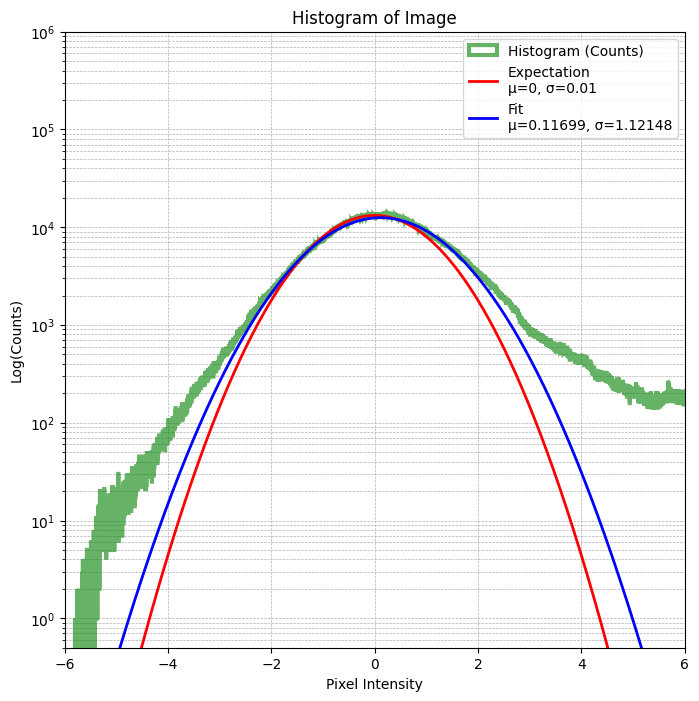

In [16]:
# Calculate the 1D histogram of the image
pixels = array.flatten()
binlen = int(len(pixels)/1000)
print(f"Length of bins={binlen}")
counts, bin_edges = np.histogram(pixels, bins=binlen, range=(-4, np.max(pixels)))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

def gaussian_fit(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

x_exp = np.linspace(-5, 5, binlen)
y_exp = gaussian_fit(x_exp, counts.max(), 0, 1)

initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
# x_fit = np.linspace(bin_centers[0]-2, bin_centers[-1], 500)
x_fit = np.linspace(-6, np.max(pixels), binlen)
y_fit = gaussian_fit(x_fit, *popt)

plt.figure(figsize=(8, 8))

log_counts = np.where(counts > 0, counts, 1) 
plt.hist(pixels, bins=binlen, range=(np.min(pixels), np.max(pixels)), color='fuchsia', edgecolor='green', alpha=0.6, label='Histogram (Counts)', histtype='step', linewidth=3)
plt.plot(x_exp, y_exp, 'red', linewidth=2, label=f'Expectation\nμ=0, σ=0.01')
plt.plot(x_fit, y_fit, 'blue', linewidth=2, label=f'Fit\nμ={popt[1]:.5f}, σ={popt[2]:.5f}')
plt.yscale('log')
plt.ylim(0.5, 1e6)
plt.xlim(-6, 6)
plt.xlabel('Pixel Intensity')
plt.ylabel('Log(Counts)')
plt.title('Histogram of Image')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()
plt.close()

(<Figure size 1000x600 with 2 Axes>, <WCSAxes: >)

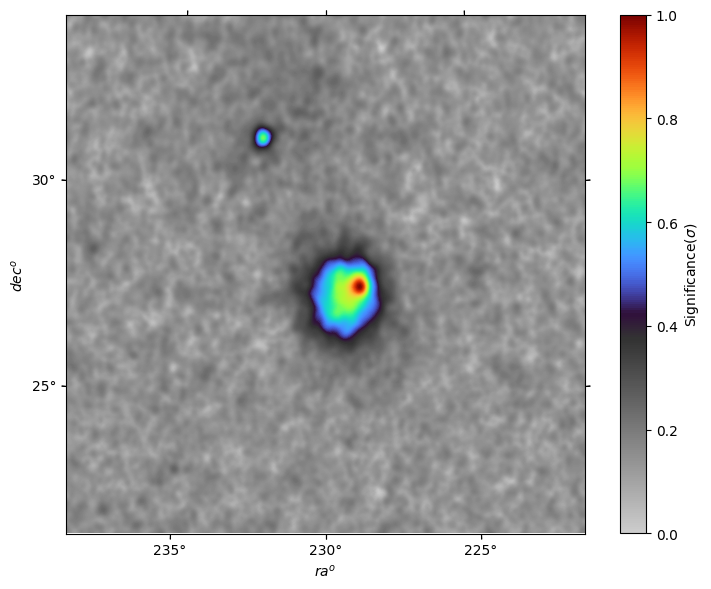

In [17]:
#Normalize the image between 0 and 1 for analysis

image = array
norm_image = (image-np.min(image))/(np.max(image)-np.min(image))
make_plots(norm_image, wcs, pixel_size, coordsys='C', threshold=0.4, vmin=0, vmax=1, contour=False, title=None, hotspots=None, save_dir=None, pdf=False, cmap='ult', figsize=(10, 6))

0.09961098977159016 0.7978628533363449


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Smeared Image with radius 0.2$^\\degree$'}>)

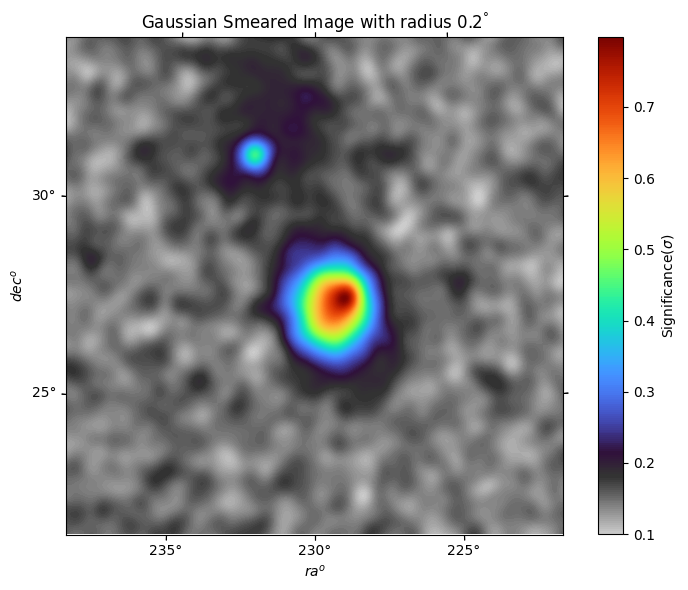

In [18]:
#Smearing Image with a gaussian for visualizing 
image_tmp = norm_image
smear_radius = 0.2
smear_image = gaussian(image_tmp, sigma=smear_radius/pixel_size)
print(np.min(smear_image), np.max(smear_image))
make_plots(smear_image, wcs, pixel_size, coordsys='C', threshold=0.2, vmin=np.min(smear_image), vmax=np.max(smear_image), title=f"Gaussian Smeared Image with radius {smear_radius}$^\degree$", cmap='ult')

72.0
Significant deviation from Gaussian on positive side at:97,  0.06284


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

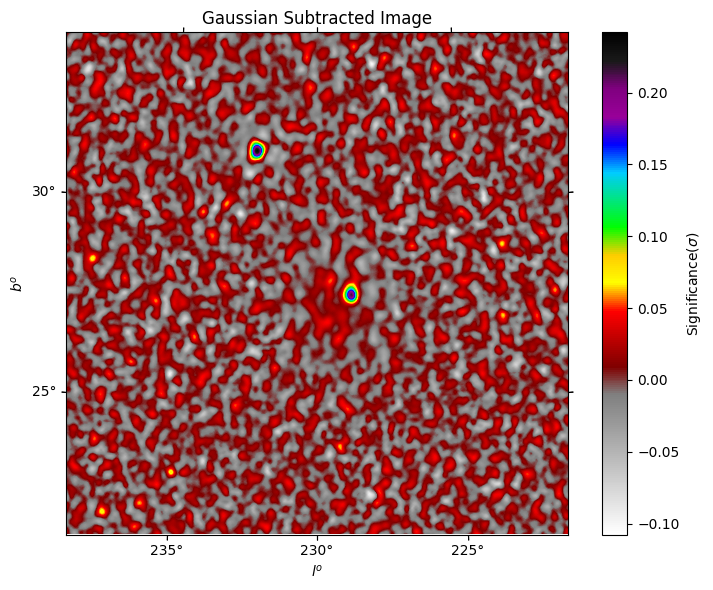

In [19]:
# Find the Difference of Gaussian (DoG) Image
psf=0.2             #PSF of the dec band
print(psf/pixel_size)
dog_image = difference_of_gaussians(norm_image, 1, psf/pixel_size)

pixels = dog_image.flatten()
sigma_resid2 = np.std(dog_image)


counts, bin_edges = np.histogram(pixels, bins=200, range=(np.min(pixels), np.max(pixels)))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2 

def gaussian_fit(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean)**2) / (2 * stddev**2))

x_exp = np.linspace(np.min(bin_edges), np.max(bin_edges), 200)
y_exp = gaussian_fit(x_exp, counts.max(), -0.1, 0.01)

initial_guess = [counts.max(), bin_centers[np.argmax(counts)], np.std(pixels)]
popt, _ = curve_fit(gaussian_fit, bin_centers, counts, p0=initial_guess)
x_fit = np.linspace(bin_centers[0], bin_centers[-1], 500)
y_fit = gaussian_fit(x_fit, *popt)


fit_interp = interp1d(x_fit, y_fit, bounds_error=False, fill_value=0)
gaussian_at_bins = fit_interp(bin_centers)

# Compute deviation mask: where histogram exceeds Gaussian expectation significantly
deviation_mask = (bin_centers > popt[1]) & (counts > 1.1 * gaussian_at_bins)

for i in range(len(deviation_mask)):
    if np.all(deviation_mask[i:]):
        j = i
        break
deviation_location = bin_centers[j]
print(f"Significant deviation from Gaussian on positive side at:{j},  {deviation_location:.5f}")
make_plots(dog_image, wcs, pixel_size, coordsys='G', threshold=0.005, hotspots=None,vmin=np.min(dog_image), vmax=np.max(dog_image), title=f'Gaussian Subtracted Image', cmap=milagro)

Number of point source blobs= 542
Number of ext source blobs= 81
Number of point source blobs= 542
Number of ext source blobs= 81
Blob Intensity 0.22408519867864385, Coords (232.179373010784 deg, 31.285205134292557 deg), Radius 36.0, Pixel Radius 0.1
Blob Intensity 0.20046999877732055, Coords (228.818810651571 deg, 27.687329926185964 deg), Radius 36.0, Pixel Radius 0.1
Blob Intensity 0.06497149765466662, Coords (237.17334618629556 deg, 22.07069421261873 deg), Radius 36.0, Pixel Radius 0.1
Blob Intensity 0.0644839911738272, Coords (237.91724377675314 deg, 28.38463790765641 deg), Radius 36.0, Pixel Radius 0.1
Blob Intensity 0.0638005824489781, Coords (234.9172424291751 deg, 23.157401688651582 deg), Radius 36.0, Pixel Radius 0.1
No of ps =  5
Blob Intensity 0.18486130501702647, Coords (232.17942876603843 deg, 31.287707154574722 deg), Radius 72.0, Pixel Radius 0.2
Blob Intensity 0.16356976071365892, Coords (228.82205092326265 deg, 27.709866729423435 deg), Radius 72.0, Pixel Radius 0.2
No o

(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

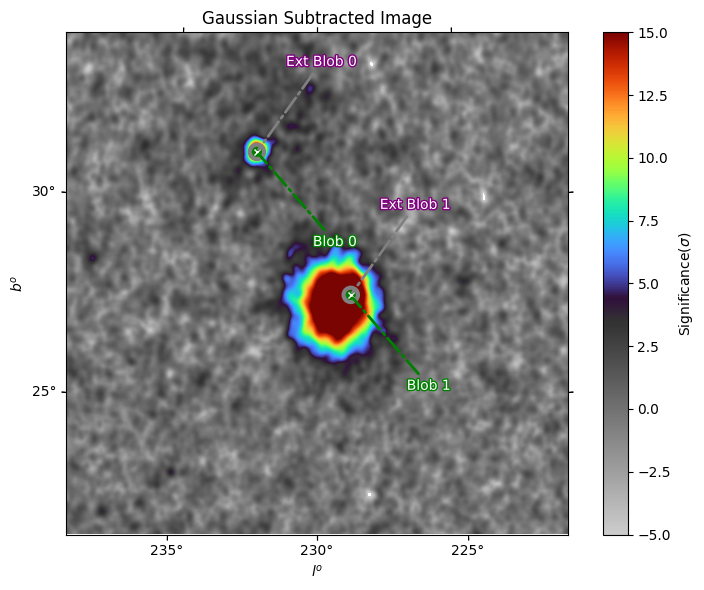

In [20]:
# Find the blobs from the DoG image
threshold_val = 0.01
psf=0.2 
ps_blobs = blob_dog(dog_image, min_sigma=0.1/pixel_size, max_sigma=psf/pixel_size, threshold=threshold_val, exclude_border=10, overlap=0.5)
print("Number of point source blobs=",len(ps_blobs))

ext_blobs = blob_dog(dog_image,min_sigma=psf/pixel_size, max_sigma=0.5/pixel_size, threshold=threshold_val, exclude_border=20, overlap=0.5)
print("Number of ext source blobs=",len(ext_blobs))

ps_blobs = ps_blobs[ps_blobs[:, 2] < psf/pixel_size]
# ext_blobs = ext_blobs[ext_blobs[:, 2] > psf/pixel_size]
print("Number of point source blobs=",len(ps_blobs))
print("Number of ext source blobs=",len(ext_blobs))


intensity_min = deviation_location
# intensity_min = 0
ps_filtered_blobs, ps_filtered_coords, ps_filtered_radius = blob_filter_intensity(ps_blobs, dog_image, intensity_min, wcs, pixel_size)
print("No of ps = ", len(ps_filtered_blobs))
ext_filtered_blobs, ext_filtered_coords, ext_filtered_radius = blob_filter_intensity(ext_blobs, dog_image, intensity_min, wcs, pixel_size)
print("No of ext = ", len(ext_filtered_blobs))

# Input Significance Image Intensity Filtering
ps_filtered_blobs2, ps_filtered_coords2, ps_filtered_radius2 = blob_filter_intensity(ps_filtered_blobs, array,5 , wcs, pixel_size)
ext_filtered_blobs3, ext_filtered_coords3, ext_filtered_radius3 = blob_filter_intensity(ext_filtered_blobs, array, 5, wcs, pixel_size)
print("No of ps = ", len(ps_filtered_blobs2))
print("No of ext = ", len(ext_filtered_blobs3))
blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs3,
}

make_plots(array, wcs, pixel_size,coordsys='G', blobs=blobs_dict,title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc'])#, figsize=(20, 10))

In [22]:
print(dog_image.min(), dog_image.max())
dog_image2 = (dog_image-np.min(dog_image))/(np.max(dog_image)-np.min(dog_image))
print(dog_image2.min(), dog_image2.max())
print(norm_image.min(), norm_image.max())

-0.10758367521778793 0.2420061919770441
0.0 1.0
0.0 1.0


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

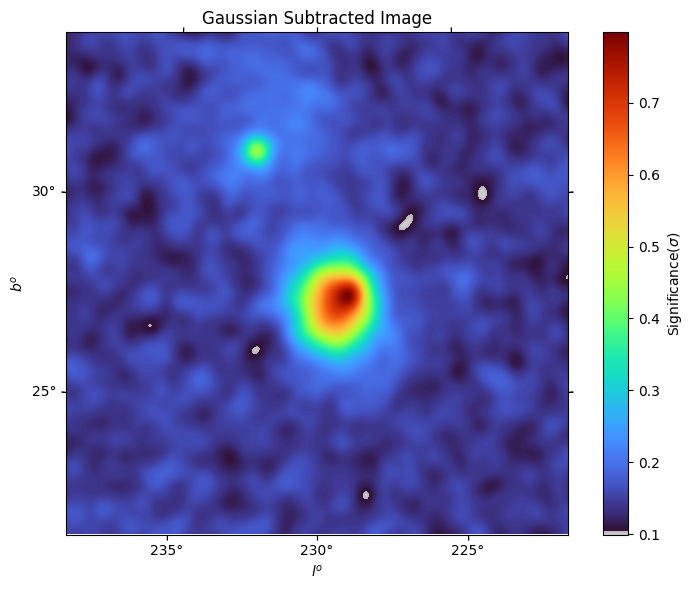

In [23]:
# lowfreq_image=norm_image-gaussian(dog_image2, sigma=100)
# lowfreq_image=norm_image-dog_image2
# lowfreq_image = gaussian(dog_image, sigma=10)
lowfreq_image=smear_image
make_plots(lowfreq_image, wcs, pixel_size, vmin=np.min(lowfreq_image), vmax=np.max(lowfreq_image), threshold=0.02,coordsys='G',title=f'Gaussian Subtracted Image', cmap='ult', labels=['4haawc'])#,

In [24]:
# Find the blobs from the Gaussian Smeared Image
ext_blobs4 = blob_dog(lowfreq_image,min_sigma=0.4/pixel_size, max_sigma=0.8/pixel_size, threshold=0.01, exclude_border=30)#, sigma_ratio=4)
print("Number of ext source blobs=",len(ext_blobs4))
# Find the blobs from the Gaussian Smeared Image
ext_blobs2 = blob_dog(lowfreq_image,min_sigma=0.8/pixel_size, max_sigma=1.5/pixel_size, threshold=0.005, exclude_border=30)#, sigma_ratio=4)
print("Number of ext source blobs=",len(ext_blobs2))
# Filter the Gaussian Blobs from above
ext_filtered_blobs4, ext_filtered_coords4, ext_filtered_radius4 = blob_filter_intensity(ext_blobs4, array, 3, wcs, pixel_size)
# Filter the Gaussian Blobs from above
ext_filtered_blobs2, ext_filtered_coords2, ext_filtered_radius2 = blob_filter_intensity(ext_blobs2, array, 4.5, wcs, pixel_size)
temp_ext = ext_filtered_blobs4+ext_filtered_blobs2

Number of ext source blobs= 15
Number of ext source blobs= 3
Blob Intensity 23.118532239382105, Coords (229.2660381774448 deg, 27.505366989465 deg), Radius 230.4, Pixel Radius 0.64
Blob Intensity 12.64954577740198, Coords (232.20772409022473 deg, 31.262243132373143 deg), Radius 144.0, Pixel Radius 0.4
Blob Intensity 3.0114190750340635, Coords (230.1683771323795 deg, 32.66601720325706 deg), Radius 144.0, Pixel Radius 0.4
Blob Intensity 21.78336311001131, Coords (229.30096618777006 deg, 27.483040262911093 deg), Radius 288.0, Pixel Radius 0.8
Blob Intensity 5.9188881982835655, Coords (232.13745149367992 deg, 31.348411899584967 deg), Radius 288.0, Pixel Radius 0.8


(<Figure size 1000x600 with 2 Axes>,
 <WCSAxes: title={'center': 'Gaussian Subtracted Image'}>)

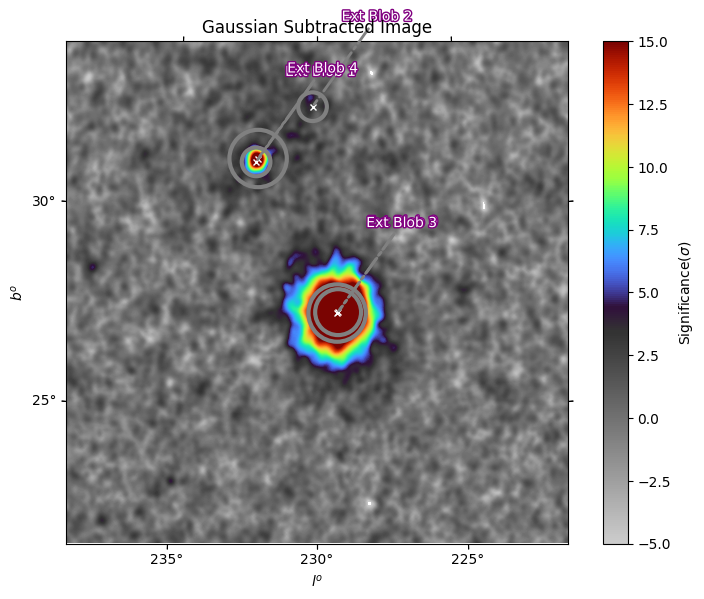

In [26]:
blobs_dict = {
    # 'psblobs': ps_filtered_blobs2,
    # 'extblobs': ext_filtered_blobs4,
    'extblobs': temp_ext,
}

make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc'])

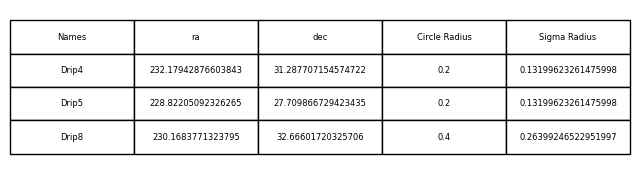

In [27]:
all_coords = ps_filtered_coords2 + ext_filtered_coords2 + ext_filtered_coords3 + ext_filtered_coords4
all_radii = ps_filtered_radius2 + ext_filtered_radius2 + ext_filtered_radius3 + ext_filtered_radius4

filtered_df = filter_overlapping_sources(all_coords, all_radii, radius_to_sigma)
t_coords = ps_filtered_coords2 + ext_filtered_coords2
t_radii = ps_filtered_radius2 + ext_filtered_radius2

# Filter ext group 4
valid_idx = remove_ext_sources_with_radius_overlap(
    t_coords, t_radii,
    ext_filtered_coords4, ext_filtered_radius4
)

# Apply filtering
ext_filtered_coords4 = [ext_filtered_coords4[i] for i in valid_idx]
ext_filtered_radius4 = [ext_filtered_radius4[i] for i in valid_idx]
ext_filtered_blobs4  = [ext_filtered_blobs4[i]  for i in valid_idx]
fig, ax = plt.subplots(figsize=(8, 2))
ax.axis('off') 

try:
    table = ax.table(cellText=filtered_df.values,
                        colLabels=filtered_df.columns,
                        cellLoc='center',
                        loc='center')

    table.scale(1, 2)
except:
    text = f"DRIPS Compilation of Result for Crab Simulation Run {file}. No Source Found"
    ax.text(0.5, 0.5, text, fontsize=12, ha='center', va='center', wrap=True)
plt.show()
plt.close(fig)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
232.17942876603843 31.287707154574722
228.82205092326265 27.709866729423435
230.1683771323795 32.66601720325706


(<Figure size 1600x800 with 2 Axes>, <WCSAxes: title={'center': 'SkyMap'}>)

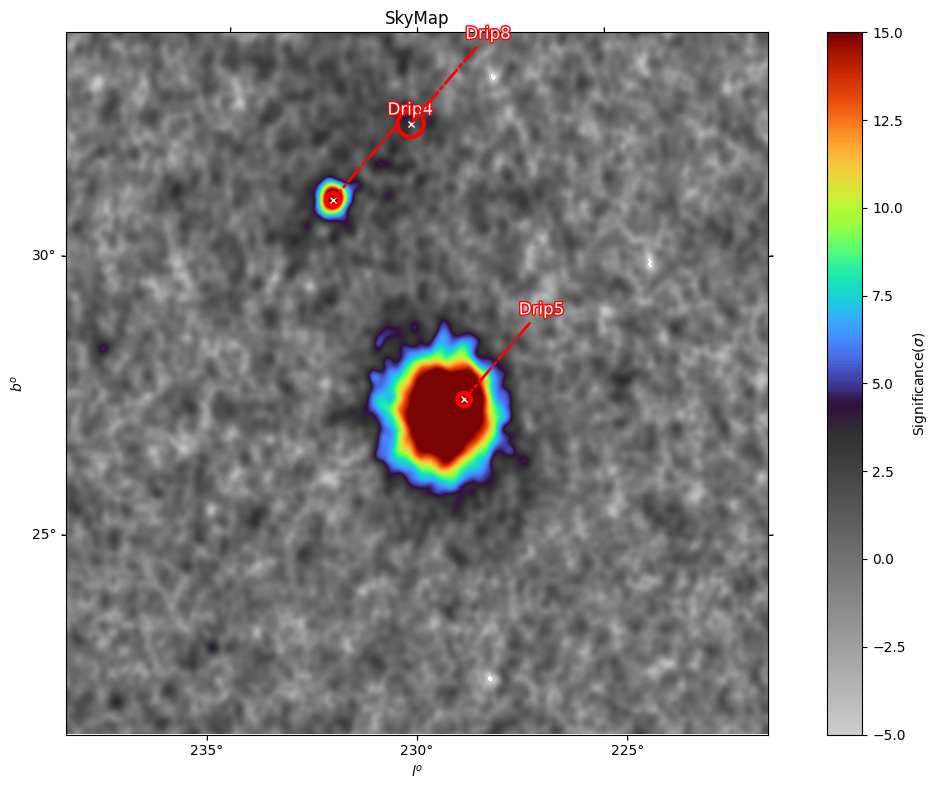

In [28]:
# Plot the Final Seeds
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
seed_final = pd.DataFrame({
    "Name": filtered_df['Names'], 
    "ra": filtered_df['ra'],
    "dec":  filtered_df['dec'], 
    "ext": filtered_df['Sigma Radius'],
    })

blobs_dict = {
    'psblobs': ps_filtered_blobs2,
    'extblobs': ext_filtered_blobs2,
}
# make_plots(array, wcs, pixel_size, coordsys='G', hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['4hawc', '4fgl', 'hgps', 'psr', 'snr'], figsize=(20, 10))
# make_plots(array, wcs, pixel_size, coordsys='G', blobs=blobs_dict, hotspots=seed_final, title=f'Gaussian Subtracted Image', cmap='ult', labels=['N'], figsize=(20, 10))
make_plots(array, wcs, pixel_size,threshold=4, coordsys='G',hotspots=seed_final, title=f'SkyMap', cmap='ult', labels=['4hawc'], save_dir='./', figsize=(16, 8))